['border_splitnet_attn_physics_limited_mask_mse_darcy_lowKarea', 'border_splitnet_attn_physics_limited_mask_mse_darcy_tvP_stats', 'border_splitnet_attn_physics_limited_mse_mask_darcy_5p0', 'border_splitnet_physics_limited_mask_mse_darcy_tvP_stats']

mean_mse_total
                                                         name    model_type  mean_mse_total
border_splitnet_attn_physics_limited_mask_mse_darcy_tvP_stats splitnet_attn        0.089239
      border_splitnet_attn_physics_limited_mse_mask_darcy_5p0 splitnet_attn        0.145242
     border_splitnet_physics_limited_mask_mse_darcy_tvP_stats      splitnet        0.162345
 border_splitnet_attn_physics_limited_mask_mse_darcy_lowKarea splitnet_attn        1.019256

mean_mse_outmask
                                                         name    model_type  mean_mse_outmask
border_splitnet_attn_physics_limited_mask_mse_darcy_tvP_stats splitnet_attn          0.077178
      border_splitnet_attn_physics_limited_mse_mask_darcy_5p0 splitne

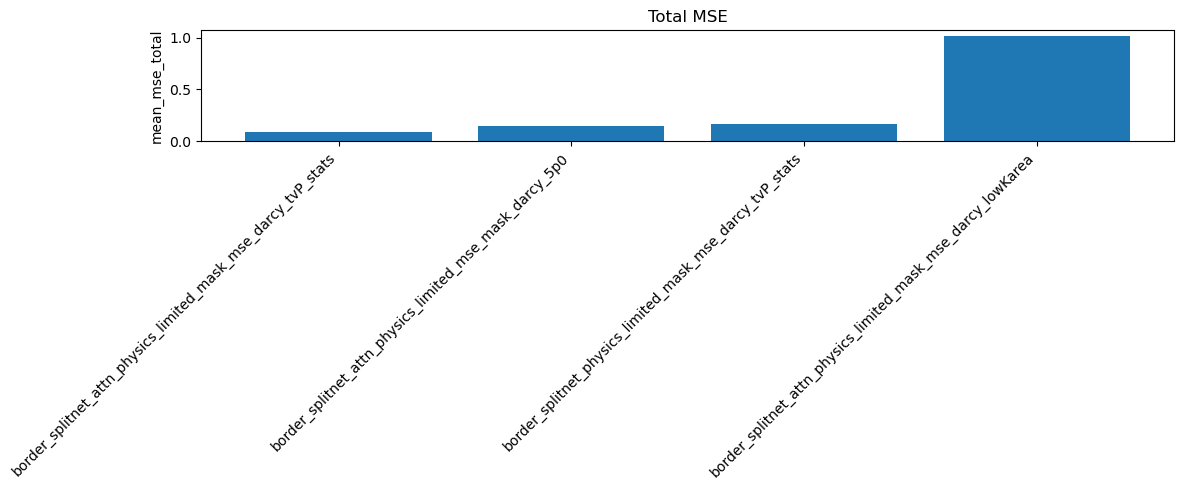

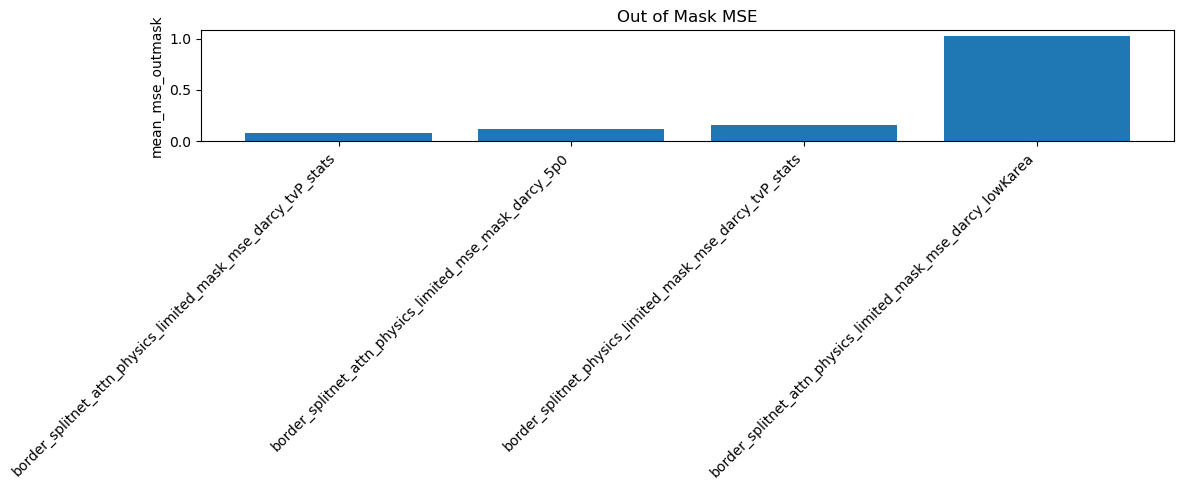

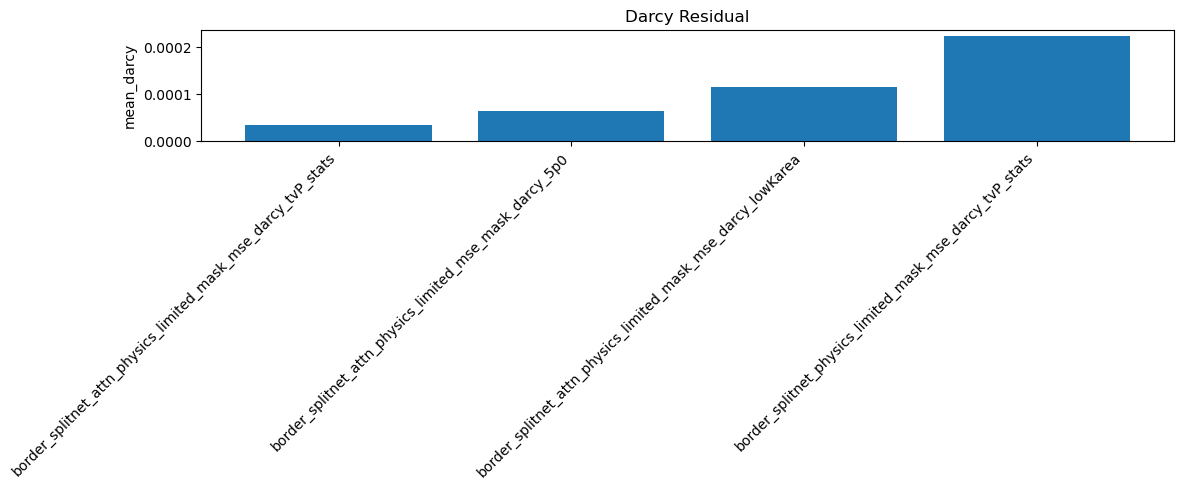

In [3]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------------------
# Load summaries
# --------------------------------------------------------

def load_results(compare_dirs):

    rows = []

    for folder in compare_dirs:

        for path in Path(folder).rglob("eval_*_summary.json"):

            with open(path, "r") as f:
                summary = json.load(f)

            config = summary.get("config", {})

            rows.append({
                "name": config.get(
                    "name",
                    path.stem.replace("eval_", "").replace("_summary", "")
                ),

                "folder": folder,

                "model_type": config.get("model_type"),
                "training_mode": config.get("training_mode"),
                "dataset_mode": config.get("train_dataset_mode"),
                "darcy_weight": config.get("darcy_weight"),

                "mean_mse_total": summary.get("mean_mse_total"),
                "mean_mse_outmask": summary.get("mean_mse_outmask"),
                "mean_mse_k": summary.get("mean_mse_k"),
                "mean_mse_p": summary.get("mean_mse_p"),
                "mean_darcy": summary.get("mean_darcy"),
            })

    return pd.DataFrame(rows)

def show_ranking(
    df,
    metric="mean_mse_total",
    ascending=True,
):

    print()
    print("=" * 80)
    print(metric)
    print("=" * 80)

    cols = [
        "name",
        "model_type",
        metric,
    ]

    print(
        df.sort_values(metric, ascending=ascending)[cols]
        .to_string(index=False)
    )


def plot_metric(
    df,
    metric="mean_mse_total",
    title=None,
):

    ordered = df.sort_values(metric)

    plt.figure(figsize=(12, 5))

    plt.bar(
        ordered["name"],
        ordered[metric]
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.ylabel(metric)

    if title:
        plt.title(title)
    else:
        plt.title(metric)

    plt.tight_layout()
    plt.show()


def compare_models(df, model_names):

    sub = df[
        df["name"].isin(model_names)
    ]

    cols = [
        "name",
        "mean_mse_total",
        "mean_mse_outmask",
        "mean_mse_k",
        "mean_mse_p",
        "mean_darcy",
    ]

    print(sub[cols].to_string(index=False))



compare_dirs = [
    # "test_eval_outputs/official_darcy",
    "test_eval_outputs/limited_prior_comparison",
]

df = load_results(compare_dirs)

print(df["name"].to_list())

show_ranking(
    df,
    metric="mean_mse_total"
)

show_ranking(
    df,
    metric="mean_mse_outmask"
)

show_ranking(
    df,
    metric="mean_darcy"
)


plot_metric(
    df,
    "mean_mse_total",
    "Total MSE"
)

plot_metric(
    df,
    "mean_mse_outmask",
    "Out of Mask MSE"
)

plot_metric(
    df,
    "mean_darcy",
    "Darcy Residual"
)